# Étape 3 - Analyse non supervisée et labellisation faible

## Objectifs

- Charger les embeddings extraits à l'étape 2.
- Réduire la dimension des features pour visualiser la structure du corpus.
- Tester plusieurs configurations de clustering avec `KMeans` et `DBSCAN`.
- Évaluer les regroupements au moyen de l'ARI sur le sous-ensemble fortement labellisé.
- Produire une première labellisation faible du pool non annoté, sans jamais mélanger labels forts et labels faibles.

## Rappel méthodologique

- Les labels forts restent dans `label_strong` et `label_strong_name`.
- Les clusters et labels faibles sont stockés dans des colonnes séparées.
- L'ARI n'est calculé que sur le sous-ensemble `strong_labeled_pool`.

# Librairies 

In [ ]:
from __future__ import annotations

from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT_CANDIDATE = Path.cwd().resolve()
for candidate in [PROJECT_ROOT_CANDIDATE, *PROJECT_ROOT_CANDIDATE.parents]:
    if (candidate / "src").exists() and (candidate / "environment.yml").exists():
        if str(candidate) not in sys.path:
            sys.path.append(str(candidate))
        break

from src.clustering_utils import (
    build_clustering_comparison_table,
    build_embedding_visualization_frame,
    build_mapping_summary_df,
    build_projection_spaces,
    compute_pca_variance_tables,
    evaluate_dbscan_configs,
    evaluate_kmeans_grid,
    label_names_from_int,
    majority_vote_mapping,
    map_clusters_to_weak_labels,
    scatter_embedding,
    build_kmeans_diagnostic_frame,
    plot_metric_barh,
    plot_cluster_label_composition,
    plot_category_counts,
    plot_representative_images_by_group
)
from src.notebook_utils import (
    build_figure_saver,
    configure_notebook,
    ensure_directory,
    find_project_root,
    set_global_seed,
)

configure_notebook(display_max_columns=100, display_max_rows=100)


# Paramètres

In [3]:
PROJECT_ROOT = find_project_root()
FEATURE_TABLE_PATH = PROJECT_ROOT / "data" / "processed" / "features" / "resnet18_feature_table.csv"
CLUSTERING_OUTPUT_DIR = ensure_directory(PROJECT_ROOT / "data" / "processed" / "clustering")
FIGURES_DIR = ensure_directory(PROJECT_ROOT / "reports" / "figures" / "clustering")

RANDOM_SEED = 42
SAVE_FIGURES = True
save_figure = build_figure_saver(FIGURES_DIR, enabled=SAVE_FIGURES)
set_global_seed(RANDOM_SEED)

PCA_COMPONENT_GRID = [2, 10, 30, 50, 100]
FINAL_KMEANS_COMPONENTS = 10
TSNE_PERPLEXITY = 30
UMAP_N_NEIGHBORS = 15
UMAP_MIN_DIST = 0.1

DBSCAN_CONFIGS = [
    {"space": "pca10", "eps": 8.0, "min_samples": 10},
    {"space": "pca10", "eps": 8.0, "min_samples": 5},
    {"space": "umap2", "eps": 1.0, "min_samples": 5},
]

print(f"PROJECT_ROOT          : {PROJECT_ROOT}")
print(f"FEATURE_TABLE_PATH    : {FEATURE_TABLE_PATH}")
print(f"CLUSTERING_OUTPUT_DIR : {CLUSTERING_OUTPUT_DIR}")
print(f"FIGURES_DIR           : {FIGURES_DIR}")
print(f"PCA_COMPONENT_GRID    : {PCA_COMPONENT_GRID}")
print(f"FINAL_KMEANS_COMPONENTS : {FINAL_KMEANS_COMPONENTS}")


PROJECT_ROOT          : /home/maxime/projects/brainscan-semisupervised
FEATURE_TABLE_PATH    : /home/maxime/projects/brainscan-semisupervised/data/processed/features/resnet18_feature_table.csv
CLUSTERING_OUTPUT_DIR : /home/maxime/projects/brainscan-semisupervised/data/processed/clustering
FIGURES_DIR           : /home/maxime/projects/brainscan-semisupervised/reports/figures/clustering
PCA_COMPONENT_GRID    : [2, 10, 30, 50, 100]
FINAL_KMEANS_COMPONENTS : 10


## 1. Charger la table de features

On travaille ici à partir des embeddings ResNet18 produits à l'étape 2.

In [4]:
# Une ligne correspond a une image et chaque colonne feat_xxxx represente une dimension de l embedding.
feature_table_df = pd.read_csv(FEATURE_TABLE_PATH)
feature_columns = [column for column in feature_table_df.columns if column.startswith("feat_")]

X = feature_table_df[feature_columns].to_numpy(dtype=np.float32)

# On isole les images avec verite terrain avec Strong mask  pour évaluer objectivement les clusters
strong_mask = feature_table_df["source_split"].eq("strong_labeled_pool").to_numpy()
y_strong = feature_table_df.loc[strong_mask, "label_strong"].astype(int).to_numpy()

overview_df = pd.DataFrame(
    {
        "metric": [
            "n_rows",
            "feature_dim",
            "n_strong_labeled",
            "n_unlabeled",
        ],
        "value": [
            len(feature_table_df),
            len(feature_columns),
            int(strong_mask.sum()),
            int((~strong_mask).sum()),
        ],
    }
)

display(overview_df)
display(feature_table_df[["relative_path", "source_split", "label_group", "label_strong", "y_ssl"]].head(5))


,metric,value
0,n_rows,1506
1,feature_dim,512
2,n_strong_labeled,100
3,n_unlabeled,1406


,relative_path,source_split,label_group,label_strong,y_ssl
0,data/raw/avec_labels/cancer/05340cd4-3bb2-459d...,strong_labeled_pool,cancer,1,1
1,data/raw/avec_labels/cancer/0c6f3641-60d9-4a76...,strong_labeled_pool,cancer,1,1
2,data/raw/avec_labels/cancer/0f718241-8f63-4b55...,strong_labeled_pool,cancer,1,1
3,data/raw/avec_labels/cancer/11a7a426-4806-401e...,strong_labeled_pool,cancer,1,1
4,data/raw/avec_labels/cancer/1c043dbb-4623-4769...,strong_labeled_pool,cancer,1,1


## 2. Standardisation et PCA

Les embeddings sont standardisés avant la réduction de dimension et le clustering.

In [5]:
# On standardise pour mettre toutes les dimensions d'embedding sur une echelle comparable avant PCA
scaler = StandardScaler() # ? Essayer avec RobusteScaler ? 
X_scaled = scaler.fit_transform(X)

# On resume ici la quantite d information conservee quand on reduit le nombre de composantes.
pca_variance_df, pca_component_summary_df = compute_pca_variance_tables(
    X_scaled,
    pca_component_grid=PCA_COMPONENT_GRID,
    random_seed=RANDOM_SEED,
)

display(pca_component_summary_df)


,n_components,cumulative_explained_variance
0,2,0.163649
1,10,0.403647
2,30,0.613328
3,50,0.715907
4,100,0.845786


Figure sauvegardée : /home/maxime/projects/brainscan-semisupervised/reports/figures/clustering/03_clustering_pca_cumulative_variance.png


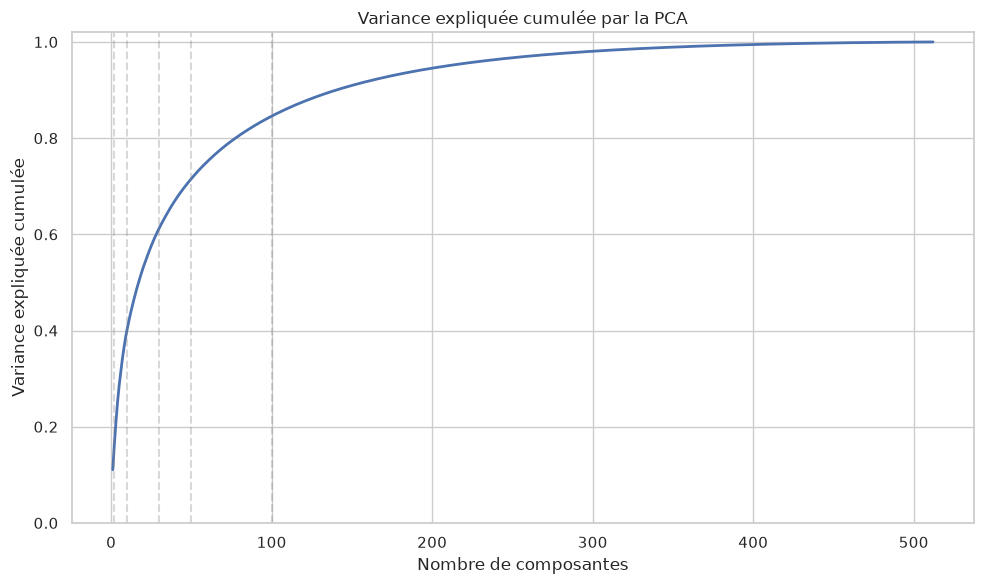

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(pca_variance_df["n_components"], pca_variance_df["cumulative_explained_variance"], linewidth=2)
for n_components in PCA_COMPONENT_GRID:
    ax.axvline(n_components, color="grey", linestyle="--", alpha=0.3)
ax.set_title("Variance expliquée cumulée par la PCA")
ax.set_xlabel("Nombre de composantes")
ax.set_ylabel("Variance expliquée cumulée")
ax.set_ylim(0, 1.02)

plt.tight_layout()
save_figure(fig, "03_clustering_pca_cumulative_variance")
plt.show()

## 3. Espaces réduits pour clustering et visualisation

On construit ici plusieurs représentations :

- `PCA(10)` pour le clustering final KMeans ;
- `PCA(2)` pour une première vue globale ;
- `t-SNE(2)` et `UMAP(2)` pour la visualisation.

In [7]:
# On construit plusieurs espaces complementaires : PCA pour le clustering, t-SNE et UMAP pour la lecture visuelle.
pca_embeddings, X_tsne2, X_umap2 = build_projection_spaces(
    X_scaled,
    pca_component_grid=PCA_COMPONENT_GRID,
    random_seed=RANDOM_SEED,
    tsne_perplexity=TSNE_PERPLEXITY,
    umap_n_neighbors=UMAP_N_NEIGHBORS,
    umap_min_dist=UMAP_MIN_DIST,
)

# On isole ici les espaces 2D et 10D qui seront reutilises plus loin dans le notebook.
X_pca2 = pca_embeddings[2]
X_pca10 = pca_embeddings[10]

embedding_viz_df = build_embedding_visualization_frame(
    feature_table_df,
    X_pca2,
    X_tsne2,
    X_umap2,
)

display(embedding_viz_df.head(5))


/home/maxime/miniforge3/envs/brainscan/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,relative_path,source_split,label_group,label_strong,label_strong_name,y_ssl,pca_1,pca_2,tsne_1,tsne_2,umap_1,umap_2
0,data/raw/avec_labels/cancer/05340cd4-3bb2-459d...,strong_labeled_pool,cancer,1,cancer,1,8.410687,-2.429701,27.442211,-36.935059,-1.841230,10.868942
1,data/raw/avec_labels/cancer/0c6f3641-60d9-4a76...,strong_labeled_pool,cancer,1,cancer,1,-8.558622,-4.020076,-23.351194,23.191591,7.666342,4.388504
2,data/raw/avec_labels/cancer/0f718241-8f63-4b55...,strong_labeled_pool,cancer,1,cancer,1,-6.108324,-2.112447,-16.886902,27.114044,8.065230,3.996714
3,data/raw/avec_labels/cancer/11a7a426-4806-401e...,strong_labeled_pool,cancer,1,cancer,1,-1.959607,6.665764,-4.994310,19.249685,9.722468,4.218983
4,data/raw/avec_labels/cancer/1c043dbb-4623-4769...,strong_labeled_pool,cancer,1,cancer,1,6.252981,14.879437,9.742553,40.289028,9.199629,2.775750


## 4. Comparer plusieurs méthodes de clustering

Les métriques suivies sont :

- l'`ARI` sur le sous-ensemble fortement labellisé ;
- le `silhouette score` sur les clusters produits ;
- le nombre de clusters obtenus ;
- le taux de bruit pour `DBSCAN`.

In [ ]:
# Toutes les methodes sont evaluees sur le meme pool fort via l ARI pour garder une comparaison equitable.
kmeans_comparison_df = evaluate_kmeans_grid(
    pca_embeddings,
    X_scaled,
    pca_component_grid=PCA_COMPONENT_GRID,
    strong_mask=strong_mask,
    y_strong=y_strong,
    random_seed=RANDOM_SEED,
)

space_lookup = {
    "pca10": X_pca10,
    "umap2": X_umap2,
}

dbscan_comparison_df = evaluate_dbscan_configs(
    space_lookup,
    DBSCAN_CONFIGS,
    strong_mask=strong_mask,
    y_strong=y_strong,
)

clustering_comparison_df = build_clustering_comparison_table(
    kmeans_comparison_df,
    dbscan_comparison_df,
)
display(clustering_comparison_df)

,method,space,ari_strong,silhouette,n_clusters,noise_ratio,eps,min_samples
0,KMeans,pca10,0.404052,0.228631,2,0.000000,NaN,NaN
1,KMeans,pca30,0.404052,0.152046,2,0.000000,NaN,NaN
2,KMeans,pca50,0.404052,0.130367,2,0.000000,NaN,NaN
3,KMeans,pca100,0.404052,0.110329,2,0.000000,NaN,NaN
4,KMeans,scaled_features,0.404052,0.093071,2,0.000000,NaN,NaN
5,KMeans,pca2,0.354144,0.546547,2,0.000000,NaN,NaN
6,DBSCAN,pca10,0.289368,0.251595,2,0.092297,8.0,10.0
7,DBSCAN,umap2,0.285424,0.730560,2,0.002656,1.0,5.0
8,DBSCAN,pca10,0.002427,NaN,1,0.053785,8.0,5.0


## 5. Retenir la meilleure configuration

Au vu de l'ARI, `KMeans` sur `PCA(10)` sert ici de configuration de référence pour générer une première labellisation faible.

In [11]:
# On fige une configuration de reference puis on donne un sens metier aux clusters grace aux labels forts.
best_kmeans_model = KMeans(n_clusters=2, random_state=RANDOM_SEED, n_init=20)
cluster_kmeans_pca10 = best_kmeans_model.fit_predict(X_pca10)

dbscan_reference_model = DBSCAN(eps=8.0, min_samples=10)
cluster_dbscan_pca10 = dbscan_reference_model.fit_predict(X_pca10)

kmeans_label_mapping = majority_vote_mapping(cluster_kmeans_pca10[strong_mask], y_strong)
weak_label_kmeans = map_clusters_to_weak_labels(
    cluster_kmeans_pca10,
    kmeans_label_mapping,
    noise_value=-1,
)
weak_label_name_kmeans = label_names_from_int(weak_label_kmeans)

dbscan_label_mapping = majority_vote_mapping(cluster_dbscan_pca10[strong_mask], y_strong)
weak_label_dbscan = map_clusters_to_weak_labels(
    cluster_dbscan_pca10,
    dbscan_label_mapping,
    noise_value=-1,
)
weak_label_name_dbscan = label_names_from_int(weak_label_dbscan)

# Ces distances donnent un premier indicateur de confiance pour chaque affectation KMeans.
kmeans_diagnostic_df = build_kmeans_diagnostic_frame(best_kmeans_model, X_pca10)

clustering_results_df = pd.concat(
    [embedding_viz_df.reset_index(drop=True), kmeans_diagnostic_df.reset_index(drop=True)],
    axis=1,
)
clustering_results_df["cluster_kmeans_pca10"] = cluster_kmeans_pca10.astype(int)
clustering_results_df["weak_label_kmeans"] = weak_label_kmeans.astype(int)
clustering_results_df["weak_label_name_kmeans"] = weak_label_name_kmeans
clustering_results_df["cluster_dbscan_pca10"] = cluster_dbscan_pca10.astype(int)
clustering_results_df["weak_label_dbscan"] = weak_label_dbscan.astype(int)
clustering_results_df["weak_label_name_dbscan"] = weak_label_name_dbscan

strong_eval_df = clustering_results_df.loc[strong_mask].copy()
weak_unlabeled_df = clustering_results_df.loc[
    clustering_results_df["source_split"] == "unlabeled_pool",
    [
        "relative_path",
        "source_split",
        "cluster_kmeans_pca10",
        "weak_label_kmeans",
        "weak_label_name_kmeans",
        "distance_to_centroid",
        "distance_margin",
    ],
].copy()

mapping_summary_df = build_mapping_summary_df(kmeans_label_mapping)

display(mapping_summary_df)
display(
    clustering_results_df[[
        "relative_path",
        "source_split",
        "cluster_kmeans_pca10",
        "weak_label_kmeans",
        "weak_label_name_kmeans",
        "distance_to_centroid",
        "distance_margin",
    ]].head(5)
)


,cluster_id,mapped_strong_label,mapped_strong_label_name
0,0,0,normal
1,1,1,cancer


,relative_path,source_split,cluster_kmeans_pca10,weak_label_kmeans,weak_label_name_kmeans,distance_to_centroid,distance_margin
0,data/raw/avec_labels/cancer/05340cd4-3bb2-459d...,strong_labeled_pool,1,1,cancer,11.267689,7.878912
1,data/raw/avec_labels/cancer/0c6f3641-60d9-4a76...,strong_labeled_pool,0,0,normal,11.510150,6.945214
2,data/raw/avec_labels/cancer/0f718241-8f63-4b55...,strong_labeled_pool,0,0,normal,13.615313,4.138657
3,data/raw/avec_labels/cancer/11a7a426-4806-401e...,strong_labeled_pool,0,0,normal,10.599339,1.602563
4,data/raw/avec_labels/cancer/1c043dbb-4623-4769...,strong_labeled_pool,1,1,cancer,19.906052,4.670147


In [12]:
# Ces tableaux croises montrent comment les clusters retrouvent, ou non, la structure des labels forts.
strong_kmeans_crosstab = pd.crosstab(
    strong_eval_df["label_strong_name"],
    strong_eval_df["cluster_kmeans_pca10"],
    rownames=["label fort"],
    colnames=["cluster KMeans PCA10"],
)

strong_dbscan_crosstab = pd.crosstab(
    strong_eval_df["label_strong_name"],
    strong_eval_df["cluster_dbscan_pca10"],
    rownames=["label fort"],
    colnames=["cluster DBSCAN PCA10"],
)

display(strong_kmeans_crosstab)
display(strong_dbscan_crosstab)


cluster KMeans PCA10,0,1
label fort,,
cancer,16,34
normal,48,2


cluster DBSCAN PCA10,-1,0,1
label fort,,,
cancer,5,27,18
normal,1,2,47


## 6. Visualiser les regroupements

On combine ici plusieurs angles de lecture :

- une projection 2D lisible du corpus ;
- une comparaison explicite des m?triques de clustering ;
- la composition r?elle des clusters et la r?partition des pseudo-labels ;
- quelques images repr?sentatives proches des centro?des KMeans.


Figure sauvegardée : /home/maxime/projects/brainscan-semisupervised/reports/figures/clustering/03_clustering_projection_and_metric_benchmarks.png


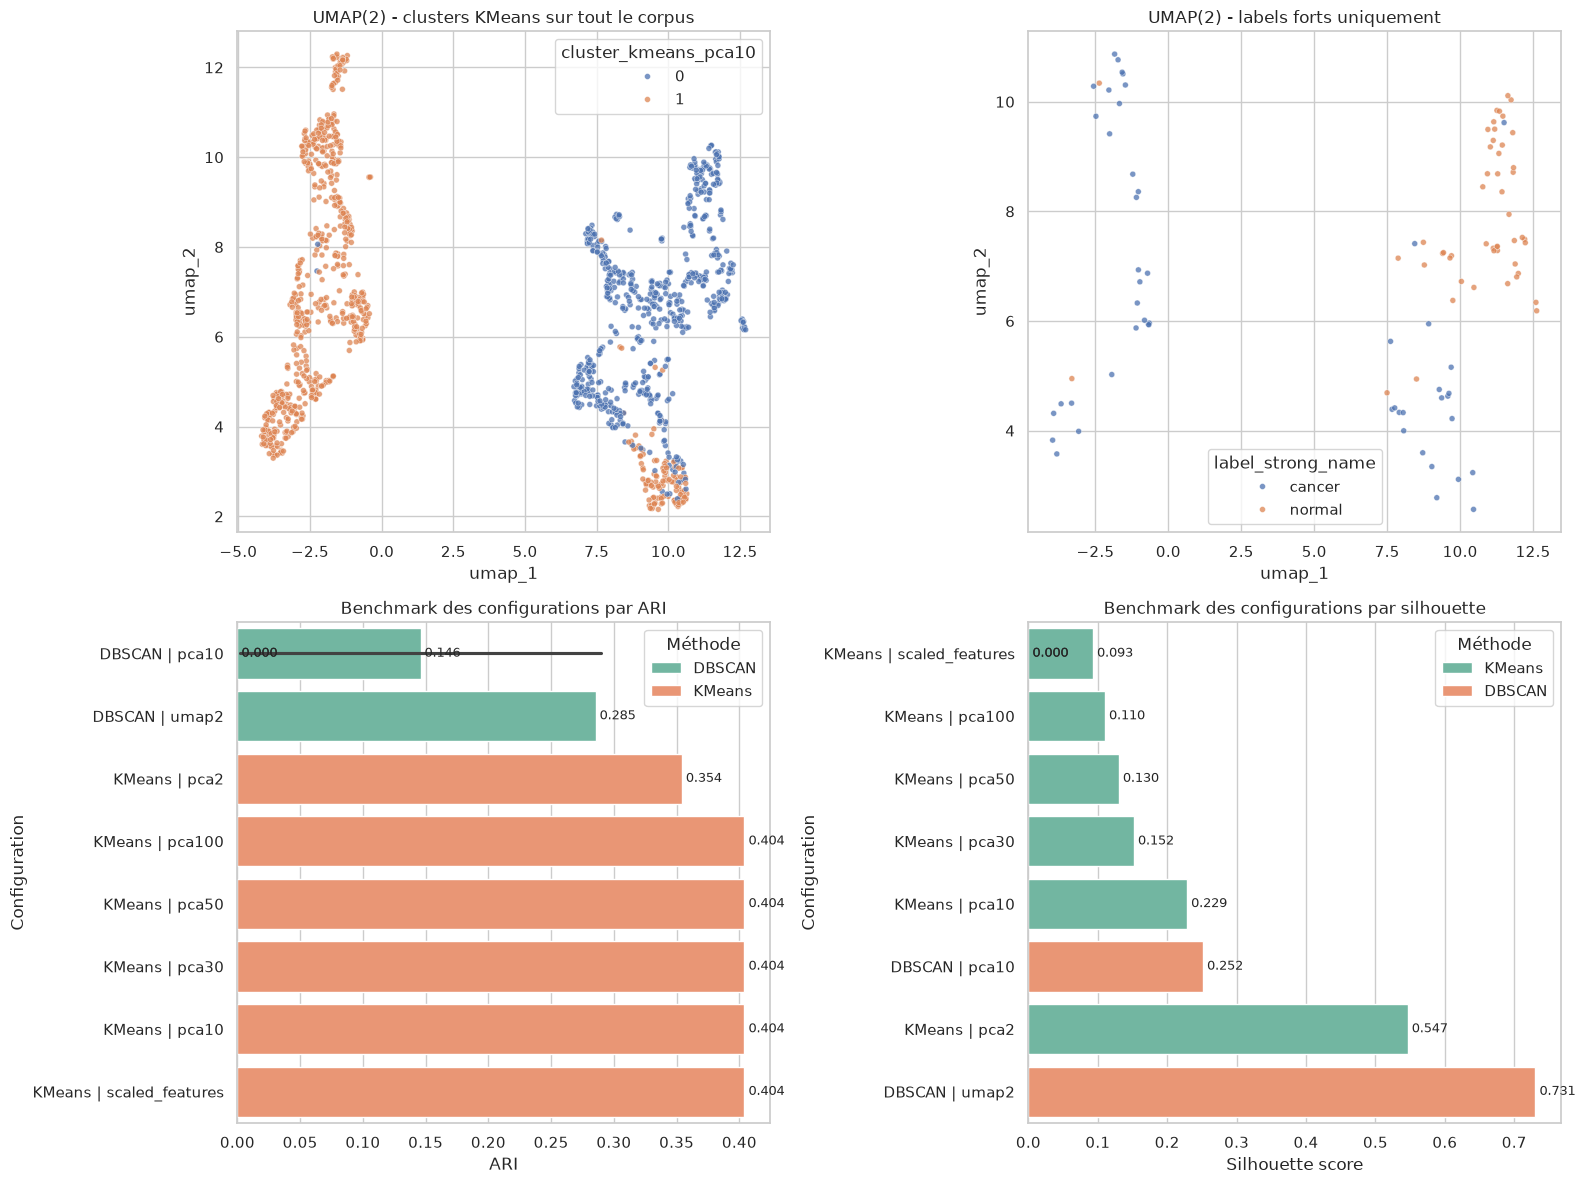

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

scatter_embedding(
    axes[0, 0],
    clustering_results_df,
    "umap_1",
    "umap_2",
    "cluster_kmeans_pca10",
    "UMAP(2) - clusters KMeans sur tout le corpus",
)
scatter_embedding(
    axes[0, 1],
    strong_eval_df,
    "umap_1",
    "umap_2",
    "label_strong_name",
    "UMAP(2) - labels forts uniquement",
)

plot_metric_barh(
    axes[1, 0],
    clustering_comparison_df,
    "ari_strong",
    "Benchmark des configurations par ARI",
    value_label="ARI",
)
plot_metric_barh(
    axes[1, 1],
    clustering_comparison_df,
    "silhouette",
    "Benchmark des configurations par silhouette",
    value_label="Silhouette score",
)

plt.tight_layout()
save_figure(fig, "03_clustering_projection_and_metric_benchmarks")
plt.show()


/home/maxime/projects/brainscan-semisupervised/src/clustering_utils.py:440: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/home/maxime/projects/brainscan-semisupervised/src/clustering_utils.py:440: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Figure sauvegardée : /home/maxime/projects/brainscan-semisupervised/reports/figures/clustering/03_clustering_cluster_composition_and_counts.png


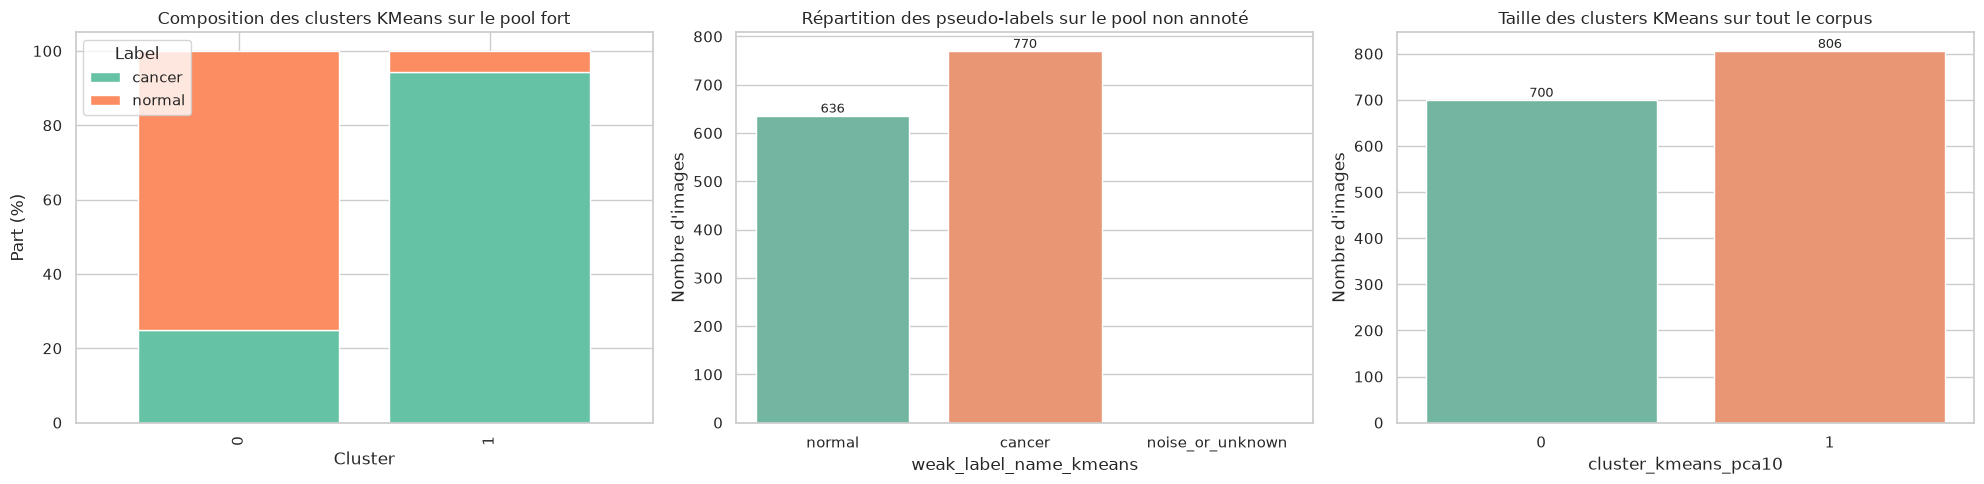

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

plot_cluster_label_composition(
    axes[0],
    strong_eval_df,
    "cluster_kmeans_pca10",
    "label_strong_name",
    "Composition des clusters KMeans sur le pool fort",
    normalize=True,
)
plot_category_counts(
    axes[1],
    weak_unlabeled_df,
    "weak_label_name_kmeans",
    "Répartition des pseudo-labels sur le pool non annoté",
    order=["normal", "cancer", "noise_or_unknown"],
)
plot_category_counts(
    axes[2],
    clustering_results_df,
    "cluster_kmeans_pca10",
    "Taille des clusters KMeans sur tout le corpus",
    order=[0, 1],
)

plt.tight_layout()
save_figure(fig, "03_clustering_cluster_composition_and_counts")
plt.show()


In [ ]:
fig = plot_representative_images_by_group(
    clustering_results_df,
    project_root=PROJECT_ROOT,
    group_col="cluster_kmeans_pca10",
    score_col="distance_to_centroid",
    title="Images les plus proches des centro?des KMeans",
    n_per_group=4,
    ascending=True,
    caption_cols=["weak_label_name_kmeans", "distance_to_centroid", "distance_margin"],
)

save_figure(fig, "03_clustering_representative_images")
plt.show()


## 7. Export des artefacts

Les artefacts exportés serviront directement à l'étape 4 pour construire un premier jeu faiblement labellisé.

In [12]:
# On exporte le benchmark, les projections enrichies et le jeu faiblement labelise pour l etape 4.
clustering_results_path = CLUSTERING_OUTPUT_DIR / "resnet18_clustering_results.csv"
comparison_path = CLUSTERING_OUTPUT_DIR / "resnet18_clustering_comparison.csv"
weak_unlabeled_path = CLUSTERING_OUTPUT_DIR / "resnet18_unlabeled_weak_labels_kmeans.csv"
pca_summary_path = CLUSTERING_OUTPUT_DIR / "resnet18_pca_component_summary.csv"
run_config_path = CLUSTERING_OUTPUT_DIR / "resnet18_clustering_run_config.json"

run_config = {
    "feature_table_path": str(FEATURE_TABLE_PATH),
    "pca_component_grid": PCA_COMPONENT_GRID,
    "final_kmeans_components": FINAL_KMEANS_COMPONENTS,
    "tsne_perplexity": TSNE_PERPLEXITY,
    "umap_n_neighbors": UMAP_N_NEIGHBORS,
    "umap_min_dist": UMAP_MIN_DIST,
    "dbscan_configs": DBSCAN_CONFIGS,
    "kmeans_label_mapping": {str(key): int(value) for key, value in kmeans_label_mapping.items()},
}

clustering_results_df.to_csv(clustering_results_path, index=False)
clustering_comparison_df.to_csv(comparison_path, index=False)
weak_unlabeled_df.to_csv(weak_unlabeled_path, index=False)
pca_component_summary_df.to_csv(pca_summary_path, index=False)
run_config_path.write_text(json.dumps(run_config, indent=2, ensure_ascii=False))

artifact_df = pd.DataFrame(
    {
        "artifact": [
            "clustering_results_csv",
            "clustering_comparison_csv",
            "weak_unlabeled_kmeans_csv",
            "pca_summary_csv",
            "run_config_json",
        ],
        "path": [
            str(clustering_results_path),
            str(comparison_path),
            str(weak_unlabeled_path),
            str(pca_summary_path),
            str(run_config_path),
        ],
    }
)

display(artifact_df)


,artifact,path
0,clustering_results_csv,/home/maxime/projects/brainscan-semisupervised...
1,clustering_comparison_csv,/home/maxime/projects/brainscan-semisupervised...
2,weak_unlabeled_kmeans_csv,/home/maxime/projects/brainscan-semisupervised...
3,pca_summary_csv,/home/maxime/projects/brainscan-semisupervised...
4,run_config_json,/home/maxime/projects/brainscan-semisupervised...


## 8. Observations et interprétation

### Ce que montre l'ARI

L'ARI permet ici d'évaluer dans quelle mesure les regroupements non supervisés retrouvent partiellement la séparation `normal` / `cancer` observée sur les labels forts. Dans ce notebook, la meilleure configuration obtient un **ARI d'environ 0,404** sur le sous-ensemble fortement labellisé. Ce score reste modéré, mais il est suffisamment supérieur à un comportement aléatoire pour indiquer que les embeddings ResNet18 captent bien une partie du signal visuel discriminant.

### Ce que montre la PCA

Le tableau `pca_component_summary_df` montre que les **2 premières composantes** ne conservent qu'environ **16,4 %** de la variance totale, ce qui confirme qu'une visualisation 2D est utile pour explorer le corpus, mais trop réductrice pour servir seule d'espace de clustering.

En revanche, **10 composantes** conservent déjà environ **40,4 %** de la variance, puis la quantité d'information récupérée augmente progressivement avec **30 composantes (61,3 %)**, **50 composantes (71,6 %)** et **100 composantes (84,6 %)**. La courbe ne présente donc pas de rupture nette, mais un aplatissement progressif.

### Lecture des résultats obtenus

- `KMeans` fournit ici les meilleurs résultats parmi les méthodes testées, en particulier lorsqu'il est appliqué après une réduction de dimension par `PCA(10)`.
- À partir de `PCA(10)`, l'`ARI` reste ensuite stable autour de **0,404** pour `PCA(30)`, `PCA(50)` et `PCA(100)`, ce qui indique que les composantes supplémentaires conservent plus de variance globale sans améliorer la séparation utile pour la tâche.
- `PCA(2)` reste utile pour la visualisation, mais son `ARI` plus faible montre qu'il compresse trop fortement l'information pour servir d'espace de travail principal.
- `DBSCAN` apparaît moins adapté à ces embeddings : il est plus sensible au choix de ses hyperparamètres et produit soit trop de bruit, soit des partitions moins cohérentes vis-à-vis des labels forts.
- Les projections `PCA`, `t-SNE` et `UMAP` mettent en évidence une structuration partielle du corpus, mais elles ne montrent pas de séparation parfaitement nette entre les classes `normal` et `cancer`.
- En conséquence, l'apprentissage non supervisé seul ne suffit pas à produire une labellisation totalement fiable, mais il fournit un signal utile pour amorcer une stratégie semi-supervisée.

### Ce que l'on peut conclure à ce stade du projet

À ce stade, plusieurs conclusions sont possibles :

- le dataset est suffisamment propre et homogène pour supporter une exploration non supervisée sérieuse ;
- les embeddings extraits par `ResNet18` contiennent une information visuelle exploitable ;
- une structure naturelle existe dans les données, mais elle ne recouvre qu'imparfaitement les labels cliniques disponibles ;
- les pseudo-labels obtenus doivent donc être considérés comme des **labels faibles** et non comme des vérités terrain.

La labellisation faible produite par `KMeans + PCA(10)` répartit le pool non annoté en **770 images pseudo-labellisées `cancer`** et **636 images pseudo-labellisées `normal`**. Cette répartition est exploitable pour l'étape suivante, mais elle devra être manipulée avec prudence.

### Décision pour l'étape 4

La configuration `KMeans + PCA(10)` est retenue comme base pragmatique pour construire un premier jeu faiblement labellisé. Ce choix est justifié par un bon compromis entre compacité de représentation, stabilité du clustering et performance mesurée par l'ARI : `PCA(10)` conserve déjà une part utile de la variance, alors que les dimensions supplémentaires n'apportent pas de gain observable sur la tâche.

L'étape suivante consistera à comparer :

- un apprentissage **supervisé** entraîné uniquement sur les labels forts ;
- un apprentissage **semi-supervisé** combinant labels forts et labels faibles issus du clustering.

Cette comparaison permettra de vérifier si les pseudo-labels produits ici apportent un gain réel de performance, ou au contraire s'ils injectent trop de bruit dans l'entraînement.

### Précaution importante

Même si une labellisation faible a été produite pour le pool non annoté, elle doit être considérée comme une approximation utile pour amorcer l'étape semi-supervisée, et non comme une vérité terrain. L'évaluation finale devra toujours reposer sur un jeu de test strictement composé de labels forts jamais vus pendant l'entraînement.

En pratique, cela signifie que les labels forts et les labels faibles devront rester stockés dans des colonnes distinctes et ne jamais être confondus dans les étapes d'entraînement, de validation et d'évaluation.